# Mark 2 — Predicted-Liver ROI and Multi-Window Feasibility

## tl;dr

Mark 1 proved that threshold calibration cannot recover the missing tumor signal. This
validation-only notebook answers the two questions that must be resolved before another
tumor model is trained:

1. Can one global predicted-liver 3D bounding-box rule contain tumors—including V104 and
   V116—without using ground-truth masks to construct the ROI?
2. Do fixed source-NIfTI HU windows improve tumor-to-liver visibility, especially for V116?

This notebook does **not** train a model and does **not** access the test split. Ground truth
is used only to score ROI containment and measure contrast after the prediction-derived ROI
has been constructed.

## Context & Methods

### Key assumptions

- The corrected v2 manifest and Mark 1 probability caches are authoritative.
- ROI construction uses only predicted-liver probabilities.
- One ROI configuration must be used for every validation patient.
- Ground-truth tumor and liver masks are evaluation labels, never ROI inputs.
- Windowed channels are generated from source NIfTI HU values, not from derived PNGs.
- V104 and V116 are guardrails, not patient-specific tuning targets.
- The test split remains locked.

### Preregistered ROI gate

A configuration is feasible only when it simultaneously achieves:

- V104 tumor-pixel containment ≥99%;
- V116 tumor-pixel containment ≥99%;
- minimum positive-patient tumor containment ≥99%;
- minimum positive-patient positive-slice containment ≥99%;
- no empty patient ROI;
- median crop-area ratio ≤60% where possible.

If no ROI passes, the next experiment must improve liver localization or use a safer
anatomy/body ROI before tumor training.

In [1]:
from __future__ import annotations

from pathlib import Path
from IPython.display import display
import hashlib
import json
import platform
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn.functional as F

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
DATASET_ROOT = Path(
    r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging"
    r"\build_corrected_20260713_214847_v2"
)
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
MARK1_DIR = PROJECT_ROOT / "mark 1" / "mark_1_outputs"
CACHE_DIR = MARK1_DIR / "probability_cache"
OUTPUT_DIR = PROJECT_ROOT / "mark 1" / "mark_2_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_MANIFEST_SHA256 = (
    "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
)
EXPECTED_CHECKPOINT_SHA256 = (
    "9c4160bbd68891f9dc4e5f04ceca4391f38c5869b3f81c72b95d4639e0572223"
)
SEED = 42
LIVER_THRESHOLDS = [0.10, 0.20, 0.30, 0.40, 0.50]
PADDINGS = [16, 32, 48, 64]
COMPONENT_MODES = ["all", "largest_3d"]
ROI_GATE = {
    "volume_104_tumor_containment": 0.99,
    "volume_116_tumor_containment": 0.99,
    "minimum_positive_patient_containment": 0.99,
    "minimum_positive_slice_containment": 0.99,
    "empty_patient_rois": 0,
    "median_crop_area_ratio": 0.60,
}
WINDOWS = {
    "broad_abdominal": (-160.0, 240.0),
    "liver_soft_tissue": (-20.0, 140.0),
    "narrow_lesion": (20.0, 120.0),
}

print(f"Python {sys.version.split()[0]} | PyTorch {torch.__version__}")
print(f"OS: {platform.platform()}")
print(f"Outputs: {OUTPUT_DIR}")

Python 3.11.15 | PyTorch 2.6.0+cu124
OS: Windows-10-10.0.26200-SP0
Outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\mark 1\mark_2_outputs


## Data

### 1. Verify Mark 1 completion, provenance, and test lock

In [2]:
def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()

assert sha256_file(MANIFEST_PATH) == EXPECTED_MANIFEST_SHA256
mark1_gate = json.loads((MARK1_DIR / "mark_1_gate_result.json").read_text())
mark1_status = json.loads((MARK1_DIR / "mark_1_status.json").read_text())
assert mark1_gate["status"] == "mark_1_diagnostic_complete"
assert mark1_gate["calibration_gate_passed"] is False
assert mark1_gate["checkpoint_sha256"] == EXPECTED_CHECKPOINT_SHA256
assert mark1_gate["test_images_accessed"] is False
assert mark1_status["cache_complete"] is True
assert mark1_status["last_completed_step"] == 10

manifest = pd.read_csv(MANIFEST_PATH)
validation_manifest = (
    manifest.loc[manifest["split"].eq("val")]
    .sort_values(["volume_id", "slice_index"])
    .reset_index(drop=True)
)
assert len(validation_manifest) == 10_685
assert validation_manifest["volume_id"].nunique() == 13
assert len(list(CACHE_DIR.glob("volume_*.npz"))) == 13
assert set(manifest["split"]) == {"train", "val", "test"}

provenance = {
    "manifest_sha256": EXPECTED_MANIFEST_SHA256,
    "mark1_checkpoint_sha256": EXPECTED_CHECKPOINT_SHA256,
    "mark1_gate_path": str(MARK1_DIR / "mark_1_gate_result.json"),
    "validation_slices": int(len(validation_manifest)),
    "validation_patients": int(validation_manifest["volume_id"].nunique()),
    "roi_uses_ground_truth": False,
    "ground_truth_used_for_scoring_only": True,
    "test_images_accessed": False,
    "windows_hu": {key: list(value) for key, value in WINDOWS.items()},
}
(OUTPUT_DIR / "mark_2_provenance.json").write_text(
    json.dumps(provenance, indent=2), encoding="utf-8"
)
print("PASS: Mark 1 complete, caches present, provenance matched, test locked.")

PASS: Mark 1 complete, caches present, provenance matched, test locked.


### 2. Load and validate probability caches

In [3]:
probability_cache = {}
coverage_rows = []
for path in sorted(CACHE_DIR.glob("volume_*.npz")):
    volume_id = int(path.stem.split("_")[-1])
    with np.load(path, allow_pickle=False) as payload:
        item = {key: payload[key] for key in payload.files}
    expected = validation_manifest.loc[
        validation_manifest["volume_id"].eq(volume_id)
    ].sort_values("slice_index")
    assert item["sample_id"].astype(str).tolist() == expected["sample_id"].astype(str).tolist()
    assert np.array_equal(item["slice_index"], expected["slice_index"].to_numpy())
    assert item["liver_probability"].shape[1:] == (256, 256)
    assert np.isfinite(item["liver_probability"]).all()
    assert np.isfinite(item["tumor_probability"]).all()
    probability_cache[volume_id] = item
    coverage_rows.append({
        "volume_id": volume_id,
        "slices": len(item["sample_id"]),
        "tumor_pixels": int(item["tumor_truth"].sum()),
        "tumor_positive_slices": int(
            item["tumor_truth"].any(axis=(1, 2)).sum()
        ),
    })

cache_coverage = pd.DataFrame(coverage_rows)
cache_coverage.to_csv(OUTPUT_DIR / "cache_coverage.csv", index=False)
display(cache_coverage)
print("PASS: 13 complete, ordered probability caches.")

,volume_id,slices,tumor_pixels,tumor_positive_slices
0,104,781,69032,122
1,105,986,0,0
2,106,771,0,0
3,107,771,1473,71
4,108,856,363698,202
5,109,756,18200,131
6,110,816,31120,130
7,111,761,1830,92
8,112,751,295,26
9,113,836,21076,135


PASS: 13 complete, ordered probability caches.


### 3. Visualize the Mark 2 decision process

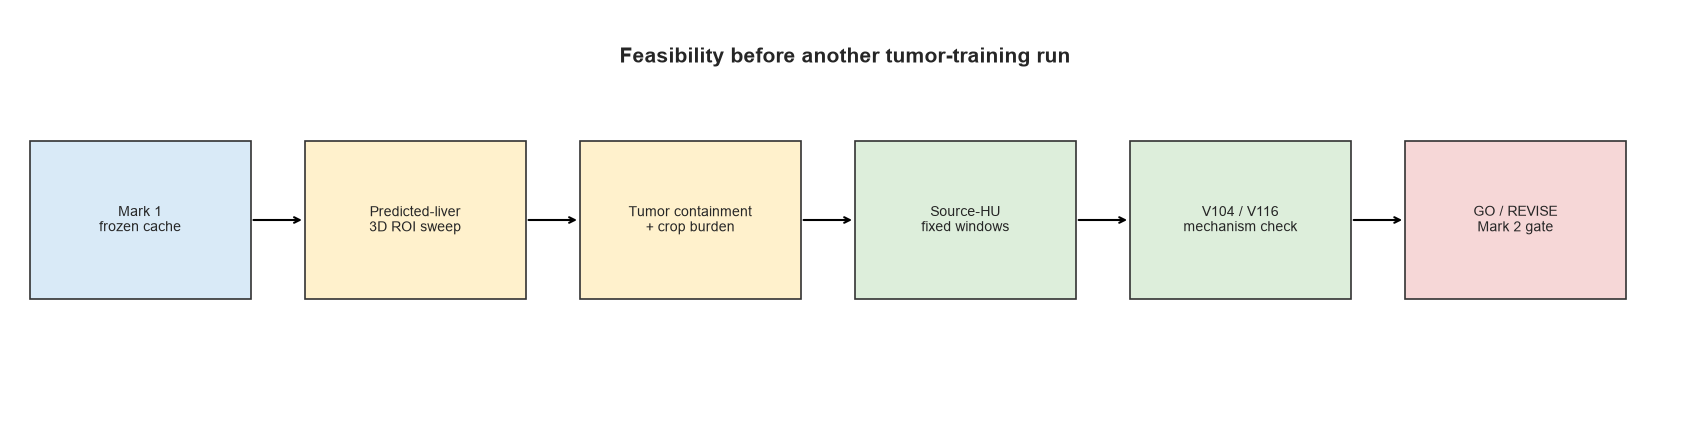

In [4]:
figure, axis = plt.subplots(figsize=(17, 4.5))
axis.set_xlim(0, 17); axis.set_ylim(0, 4); axis.axis("off")
stages = [
    (0.2, "Mark 1\nfrozen cache", "#D9EAF7"),
    (3.0, "Predicted-liver\n3D ROI sweep", "#FFF1CC"),
    (5.8, "Tumor containment\n+ crop burden", "#FFF1CC"),
    (8.6, "Source-HU\nfixed windows", "#DDEEDB"),
    (11.4, "V104 / V116\nmechanism check", "#DDEEDB"),
    (14.2, "GO / REVISE\nMark 2 gate", "#F6D7D7"),
]
for x, label, color in stages:
    axis.add_patch(plt.Rectangle(
        (x, 1.25), 2.25, 1.5, facecolor=color,
        edgecolor="#333333", linewidth=1.2,
    ))
    axis.text(x + 1.125, 2.0, label, ha="center", va="center", fontsize=10)
for left, right in zip(stages[:-1], stages[1:]):
    axis.annotate("", xy=(right[0], 2.0), xytext=(left[0] + 2.25, 2.0),
                  arrowprops={"arrowstyle": "->", "linewidth": 1.5})
axis.text(8.5, 3.5, "Feasibility before another tumor-training run",
          ha="center", fontsize=15, weight="bold")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "mark_2_process_map.png", dpi=170, bbox_inches="tight")
plt.show()

## Results

### 4. Construct prediction-only 3D ROIs

The box is derived exclusively from predicted-liver probabilities. `largest_3d` retains the
largest connected 3D component; `all` encloses all predicted liver voxels. Padding is applied
in-plane after projection to a common 3D box.

In [5]:
from scipy import ndimage

def predicted_liver_mask(probability, threshold, component_mode):
    mask = probability.astype(np.float32) >= threshold
    if component_mode == "all" or not mask.any():
        return mask
    labels, count = ndimage.label(mask, structure=np.ones((3, 3, 3), dtype=np.uint8))
    if count == 0:
        return mask
    sizes = np.bincount(labels.ravel())
    sizes[0] = 0
    return labels == sizes.argmax()

def bbox_from_mask(mask, padding=0):
    if not mask.any():
        return None
    _, ys, xs = np.where(mask)
    y0 = max(int(ys.min()) - padding, 0)
    y1 = min(int(ys.max()) + 1 + padding, 256)
    x0 = max(int(xs.min()) - padding, 0)
    x1 = min(int(xs.max()) + 1 + padding, 256)
    return (y0, y1, x0, x1)

def padded_box(base_box, padding):
    if base_box is None:
        return None
    y0, y1, x0, x1 = base_box
    return (
        max(y0 - padding, 0), min(y1 + padding, 256),
        max(x0 - padding, 0), min(x1 + padding, 256),
    )

def score_roi(volume_id, item, threshold, padding, component_mode, base_box):
    box = padded_box(base_box, padding)
    truth = item["tumor_truth"].astype(bool)
    positive_slices = truth.any(axis=(1, 2))
    if box is None:
        contained = np.zeros_like(truth)
        area_ratio = 0.0
    else:
        y0, y1, x0, x1 = box
        contained = np.zeros_like(truth)
        contained[:, y0:y1, x0:x1] = truth[:, y0:y1, x0:x1]
        area_ratio = ((y1 - y0) * (x1 - x0)) / (256 * 256)
    contained_pixels = int(contained.sum())
    truth_pixels = int(truth.sum())
    contained_positive_slices = (
        contained.any(axis=(1, 2)) & positive_slices
    ).sum()
    return {
        "volume_id": volume_id,
        "liver_threshold": threshold,
        "padding": padding,
        "component_mode": component_mode,
        "roi_empty": box is None,
        "y0": box[0] if box else np.nan,
        "y1": box[1] if box else np.nan,
        "x0": box[2] if box else np.nan,
        "x1": box[3] if box else np.nan,
        "crop_area_ratio": area_ratio,
        "tumor_pixels": truth_pixels,
        "tumor_pixel_containment": (
            contained_pixels / truth_pixels if truth_pixels else np.nan
        ),
        "positive_slices": int(positive_slices.sum()),
        "positive_slice_containment": (
            contained_positive_slices / positive_slices.sum()
            if positive_slices.any() else np.nan
        ),
    }

roi_patient_rows = []
for threshold in LIVER_THRESHOLDS:
    for component_mode in COMPONENT_MODES:
        for volume_id, item in probability_cache.items():
            liver_mask = predicted_liver_mask(
                item["liver_probability"], threshold, component_mode
            )
            base_box = bbox_from_mask(liver_mask)
            for padding in PADDINGS:
                roi_patient_rows.append(
                    score_roi(
                        volume_id, item, threshold, padding,
                        component_mode, base_box,
                    )
                )
roi_patient_results = pd.DataFrame(roi_patient_rows)
roi_patient_results.to_csv(OUTPUT_DIR / "roi_patient_results.csv", index=False)
print(f"Evaluated {len(roi_patient_results):,} patient/configuration rows.")

Evaluated 520 patient/configuration rows.


### 5. Aggregate ROI configurations and apply the feasibility gate

In [6]:
configuration_rows = []
group_columns = ["liver_threshold", "padding", "component_mode"]
for keys, group in roi_patient_results.groupby(group_columns, sort=True):
    threshold, padding, component_mode = keys
    positive = group.loc[group["tumor_pixels"].gt(0)]
    indexed = group.set_index("volume_id")
    configuration_rows.append({
        "liver_threshold": threshold,
        "padding": padding,
        "component_mode": component_mode,
        "volume_104_tumor_containment": indexed.at[104, "tumor_pixel_containment"],
        "volume_116_tumor_containment": indexed.at[116, "tumor_pixel_containment"],
        "minimum_positive_patient_containment": positive["tumor_pixel_containment"].min(),
        "mean_positive_patient_containment": positive["tumor_pixel_containment"].mean(),
        "minimum_positive_slice_containment": positive["positive_slice_containment"].min(),
        "median_crop_area_ratio": group["crop_area_ratio"].median(),
        "maximum_crop_area_ratio": group["crop_area_ratio"].max(),
        "empty_patient_rois": int(group["roi_empty"].sum()),
    })

roi_configurations = pd.DataFrame(configuration_rows)
roi_configurations["hard_containment_gate_passed"] = (
    roi_configurations["volume_104_tumor_containment"].ge(0.99)
    & roi_configurations["volume_116_tumor_containment"].ge(0.99)
    & roi_configurations["minimum_positive_patient_containment"].ge(0.99)
    & roi_configurations["minimum_positive_slice_containment"].ge(0.99)
    & roi_configurations["empty_patient_rois"].eq(0)
)
roi_configurations["efficient_roi_gate_passed"] = (
    roi_configurations["hard_containment_gate_passed"]
    & roi_configurations["median_crop_area_ratio"].le(0.60)
)
roi_configurations.to_csv(OUTPUT_DIR / "roi_configuration_results.csv", index=False)

eligible = roi_configurations.loc[
    roi_configurations["efficient_roi_gate_passed"]
].copy()
fallback = roi_configurations.loc[
    roi_configurations["hard_containment_gate_passed"]
].copy()
candidate_pool = eligible if not eligible.empty else fallback
if not candidate_pool.empty:
    selected_roi = candidate_pool.sort_values(
        ["median_crop_area_ratio", "minimum_positive_patient_containment"],
        ascending=[True, False],
    ).iloc[0]
else:
    selected_roi = roi_configurations.sort_values(
        [
            "minimum_positive_patient_containment",
            "minimum_positive_slice_containment",
            "median_crop_area_ratio",
        ],
        ascending=[False, False, True],
    ).iloc[0]

display(
    roi_configurations.sort_values(
        [
            "hard_containment_gate_passed",
            "minimum_positive_patient_containment",
            "median_crop_area_ratio",
        ],
        ascending=[False, False, True],
    ).head(20)
)
print("Selected diagnostic ROI:", selected_roi.to_dict())

,liver_threshold,padding,component_mode,volume_104_tumor_containment,volume_116_tumor_containment,minimum_positive_patient_containment,mean_positive_patient_containment,minimum_positive_slice_containment,median_crop_area_ratio,maximum_crop_area_ratio,empty_patient_rois,hard_containment_gate_passed,efficient_roi_gate_passed
33,0.5,16,largest_3d,1.0,1.0,1.0,1.0,1.0,0.427002,0.533203,0,True,True
25,0.4,16,largest_3d,1.0,1.0,1.0,1.0,1.0,0.429688,0.533203,0,True,True
17,0.3,16,largest_3d,1.0,1.0,1.0,1.0,1.0,0.433594,0.533203,0,True,True
9,0.2,16,largest_3d,1.0,1.0,1.0,1.0,1.0,0.437286,0.535980,0,True,True
1,0.1,16,largest_3d,1.0,1.0,1.0,1.0,1.0,0.447113,0.541718,0,True,True
32,0.5,16,all,1.0,1.0,1.0,1.0,1.0,0.580078,0.726318,0,True,True
24,0.4,16,all,1.0,1.0,1.0,1.0,1.0,0.581863,0.772705,0,True,True
35,0.5,32,largest_3d,1.0,1.0,1.0,1.0,1.0,0.594727,0.721649,0,True,True
27,0.4,32,largest_3d,1.0,1.0,1.0,1.0,1.0,0.598145,0.721649,0,True,True
19,0.3,32,largest_3d,1.0,1.0,1.0,1.0,1.0,0.607773,0.721649,0,True,False


Selected diagnostic ROI: {'liver_threshold': 0.5, 'padding': 16, 'component_mode': 'largest_3d', 'volume_104_tumor_containment': 1.0, 'volume_116_tumor_containment': 1.0, 'minimum_positive_patient_containment': 1.0, 'mean_positive_patient_containment': 1.0, 'minimum_positive_slice_containment': 1.0, 'median_crop_area_ratio': 0.427001953125, 'maximum_crop_area_ratio': 0.533203125, 'empty_patient_rois': 0, 'hard_containment_gate_passed': True, 'efficient_roi_gate_passed': True}


### 6. Visualize ROI containment, patient risk, and crop burden

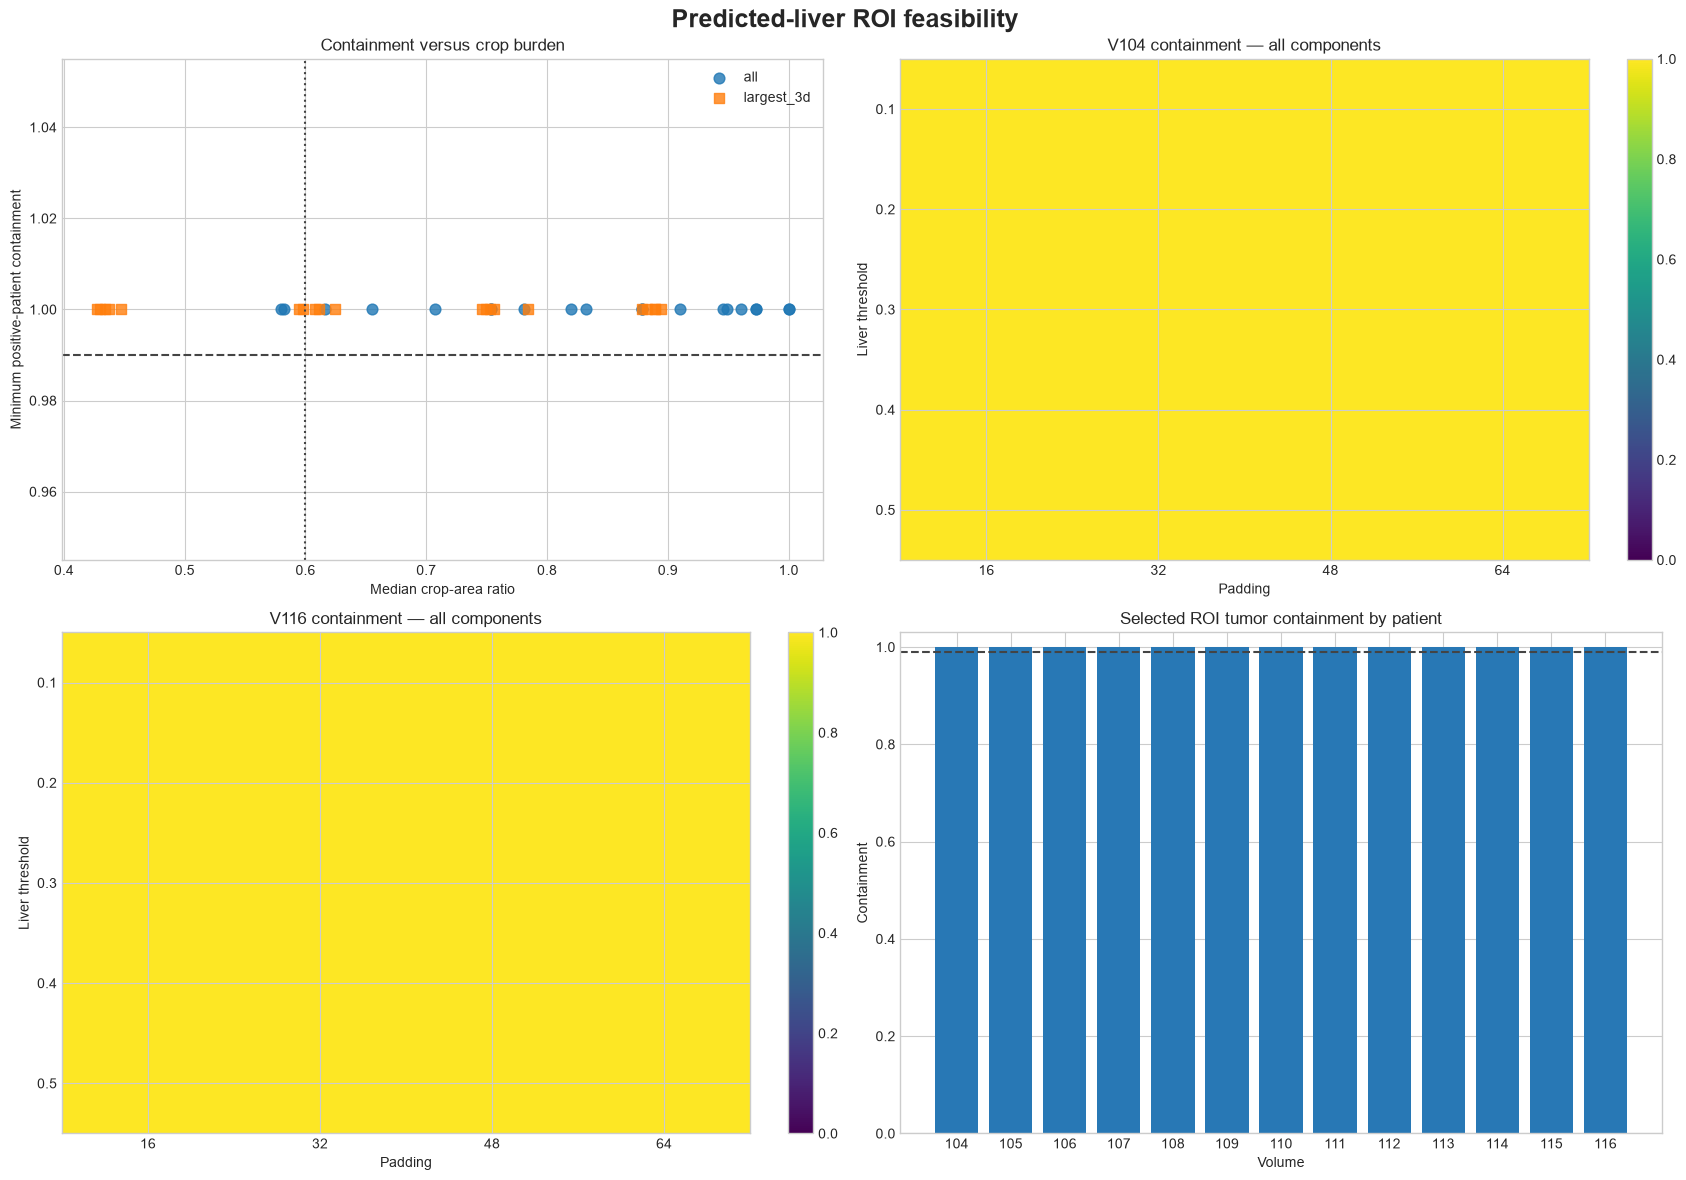

In [7]:
figure, axes = plt.subplots(2, 2, figsize=(17, 12))
for mode, marker in [("all", "o"), ("largest_3d", "s")]:
    subset = roi_configurations.loc[roi_configurations["component_mode"].eq(mode)]
    axes[0, 0].scatter(
        subset["median_crop_area_ratio"],
        subset["minimum_positive_patient_containment"],
        label=mode, marker=marker, s=60, alpha=0.8,
    )
axes[0, 0].axhline(0.99, linestyle="--", color="#444444")
axes[0, 0].axvline(0.60, linestyle=":", color="#444444")
axes[0, 0].set_xlabel("Median crop-area ratio")
axes[0, 0].set_ylabel("Minimum positive-patient containment")
axes[0, 0].set_title("Containment versus crop burden")
axes[0, 0].legend()

pivot_104 = roi_configurations.loc[
    roi_configurations["component_mode"].eq("all")
].pivot(index="liver_threshold", columns="padding",
        values="volume_104_tumor_containment")
image = axes[0, 1].imshow(pivot_104, vmin=0, vmax=1, cmap="viridis", aspect="auto")
axes[0, 1].set_xticks(range(len(pivot_104.columns)), pivot_104.columns)
axes[0, 1].set_yticks(range(len(pivot_104.index)), pivot_104.index)
axes[0, 1].set_xlabel("Padding"); axes[0, 1].set_ylabel("Liver threshold")
axes[0, 1].set_title("V104 containment — all components")
figure.colorbar(image, ax=axes[0, 1], fraction=0.046)

pivot_116 = roi_configurations.loc[
    roi_configurations["component_mode"].eq("all")
].pivot(index="liver_threshold", columns="padding",
        values="volume_116_tumor_containment")
image = axes[1, 0].imshow(pivot_116, vmin=0, vmax=1, cmap="viridis", aspect="auto")
axes[1, 0].set_xticks(range(len(pivot_116.columns)), pivot_116.columns)
axes[1, 0].set_yticks(range(len(pivot_116.index)), pivot_116.index)
axes[1, 0].set_xlabel("Padding"); axes[1, 0].set_ylabel("Liver threshold")
axes[1, 0].set_title("V116 containment — all components")
figure.colorbar(image, ax=axes[1, 0], fraction=0.046)

selected_filter = (
    roi_patient_results["liver_threshold"].eq(selected_roi["liver_threshold"])
    & roi_patient_results["padding"].eq(selected_roi["padding"])
    & roi_patient_results["component_mode"].eq(selected_roi["component_mode"])
)
selected_patients = roi_patient_results.loc[selected_filter].sort_values("volume_id")
axes[1, 1].bar(
    selected_patients["volume_id"].astype(str),
    selected_patients["tumor_pixel_containment"].fillna(1.0),
    color=[
        "#2878B5" if value >= 0.99 else "#F28E2B"
        for value in selected_patients["tumor_pixel_containment"].fillna(1.0)
    ],
)
axes[1, 1].axhline(0.99, linestyle="--", color="#444444")
axes[1, 1].set_ylim(0, 1.03)
axes[1, 1].set_title("Selected ROI tumor containment by patient")
axes[1, 1].set_xlabel("Volume"); axes[1, 1].set_ylabel("Containment")

figure.suptitle("Predicted-liver ROI feasibility", fontsize=18, weight="bold")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "roi_feasibility_dashboard.png",
               dpi=170, bbox_inches="tight")
plt.show()

### 7. Inspect selected predicted ROIs for V104 and V116

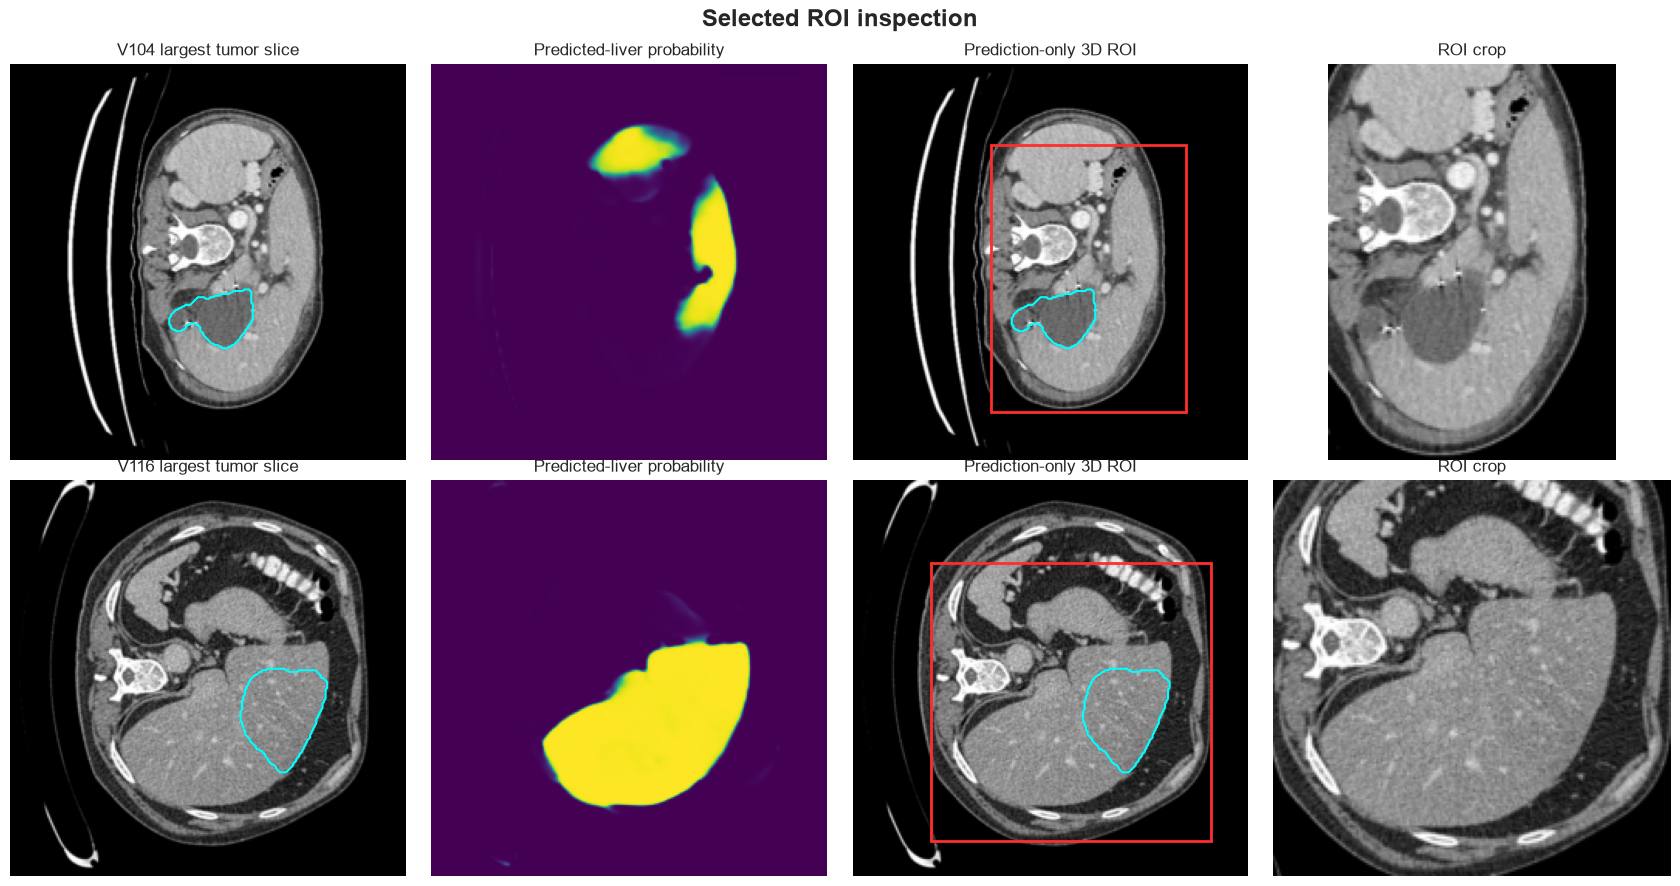

In [8]:
def load_derived_image(sample_id):
    row = validation_manifest.loc[
        validation_manifest["sample_id"].eq(sample_id)
    ].iloc[0]
    with Image.open(DATASET_ROOT / row["image_path"]) as handle:
        return np.asarray(handle.convert("L"), dtype=np.float32) / 255.0

def selected_box_for_volume(volume_id):
    row = roi_patient_results.loc[
        selected_filter & roi_patient_results["volume_id"].eq(volume_id)
    ].iloc[0]
    if row["roi_empty"]:
        return None
    return tuple(int(row[key]) for key in ("y0", "y1", "x0", "x1"))

figure, axes = plt.subplots(2, 4, figsize=(17, 9))
for row_axes, volume_id in zip(axes, [104, 116]):
    item = probability_cache[volume_id]
    tumor_sizes = item["tumor_truth"].sum(axis=(1, 2))
    index = int(np.argmax(tumor_sizes))
    sample_id = str(item["sample_id"][index])
    image = load_derived_image(sample_id)
    liver_probability = item["liver_probability"][index].astype(np.float32)
    tumor = item["tumor_truth"][index].astype(bool)
    box = selected_box_for_volume(volume_id)

    row_axes[0].imshow(image, cmap="gray", vmin=0, vmax=1)
    row_axes[0].contour(tumor, levels=[0.5], colors=["#00FFFF"])
    row_axes[0].set_title(f"V{volume_id} largest tumor slice")
    row_axes[1].imshow(liver_probability, cmap="viridis", vmin=0, vmax=1)
    row_axes[1].set_title("Predicted-liver probability")
    row_axes[2].imshow(image, cmap="gray", vmin=0, vmax=1)
    row_axes[2].contour(tumor, levels=[0.5], colors=["#00FFFF"])
    if box:
        y0, y1, x0, x1 = box
        row_axes[2].add_patch(plt.Rectangle(
            (x0, y0), x1 - x0, y1 - y0,
            fill=False, edgecolor="#FF2D2D", linewidth=2,
        ))
    row_axes[2].set_title("Prediction-only 3D ROI")
    if box:
        y0, y1, x0, x1 = box
        crop = image[y0:y1, x0:x1]
        row_axes[3].imshow(crop, cmap="gray", vmin=0, vmax=1)
    else:
        row_axes[3].text(0.5, 0.5, "EMPTY ROI", ha="center", va="center")
    row_axes[3].set_title("ROI crop")
    for axis in row_axes:
        axis.axis("off")
figure.suptitle("Selected ROI inspection", fontsize=17, weight="bold")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "selected_roi_v104_v116.png",
               dpi=170, bbox_inches="tight")
plt.show()

### 8. Measure fixed-window source-HU visibility

This step reads only train and validation source NIfTI files. It records tumor/liver
contrast and saturation for each fixed window. Validation results diagnose V104/V116;
training distributions provide the comparison reference.

In [9]:
import nibabel as nib

def apply_window(hu, lower, upper):
    return np.clip((hu - lower) / (upper - lower), 0.0, 1.0)

def transform_labels(labels, transform):
    if transform == "identity":
        return labels
    if transform == "rot180":
        return np.rot90(labels, 2).copy()
    raise ValueError(transform)

def window_statistics(split):
    rows = []
    split_manifest = manifest.loc[
        manifest["split"].eq(split) & manifest["tumor_pixels"].gt(0)
    ]
    for volume_id, group in split_manifest.groupby("volume_id", sort=True):
        first = group.iloc[0]
        ct = nib.load(str(first["source_volume_path"]))
        segmentation = nib.load(str(first["source_segmentation_path"]))
        transform = str(first["transform_applied"])
        for row in group.sort_values("slice_index").itertuples(index=False):
            z = int(row.slice_index)
            hu = np.asanyarray(ct.dataobj[:, :, z]).astype(np.float32)
            labels = transform_labels(
                np.asanyarray(segmentation.dataobj[:, :, z]).astype(np.uint8),
                transform,
            )
            tumor = hu[labels == 2]
            liver = hu[labels == 1]
            if not tumor.size or not liver.size:
                continue
            base = {
                "split": split,
                "sample_id": row.sample_id,
                "volume_id": int(volume_id),
                "slice_index": z,
                "tumor_pixels_native": int(tumor.size),
                "median_contrast_hu": float(np.median(tumor) - np.median(liver)),
            }
            for name, (lower, upper) in WINDOWS.items():
                tumor_window = apply_window(tumor, lower, upper)
                liver_window = apply_window(liver, lower, upper)
                rows.append({
                    **base,
                    "window": name,
                    "lower_hu": lower,
                    "upper_hu": upper,
                    "tumor_median_windowed": float(np.median(tumor_window)),
                    "liver_median_windowed": float(np.median(liver_window)),
                    "absolute_median_separation": float(
                        abs(np.median(tumor_window) - np.median(liver_window))
                    ),
                    "tumor_low_saturation_pct": float(100 * (tumor <= lower).mean()),
                    "tumor_high_saturation_pct": float(100 * (tumor >= upper).mean()),
                    "liver_low_saturation_pct": float(100 * (liver <= lower).mean()),
                    "liver_high_saturation_pct": float(100 * (liver >= upper).mean()),
                })
    return pd.DataFrame(rows)

window_slice_statistics = pd.concat(
    [window_statistics("train"), window_statistics("val")],
    ignore_index=True,
)
window_slice_statistics.to_csv(
    OUTPUT_DIR / "multiwindow_slice_statistics.csv", index=False
)
window_summary = (
    window_slice_statistics.groupby(["split", "window"])
    .agg(
        slices=("sample_id", "size"),
        median_absolute_separation=("absolute_median_separation", "median"),
        median_tumor_low_saturation_pct=("tumor_low_saturation_pct", "median"),
        median_tumor_high_saturation_pct=("tumor_high_saturation_pct", "median"),
    )
    .reset_index()
)
window_summary.to_csv(OUTPUT_DIR / "multiwindow_summary.csv", index=False)
display(window_summary)

,split,window,slices,median_absolute_separation,median_tumor_low_saturation_pct,median_tumor_high_saturation_pct
0,train,broad_abdominal,4923,0.09750,0.000000,0.000000
1,train,liver_soft_tissue,4923,0.24375,0.138122,0.330868
2,train,narrow_lesion,4923,0.38000,7.638889,2.795031
3,val,broad_abdominal,1042,0.10250,0.000000,0.000000
4,val,liver_soft_tissue,1042,0.25625,0.000000,0.294155
5,val,narrow_lesion,1042,0.38000,5.250704,2.355586


### 9. Visualize window separability and V104/V116 examples

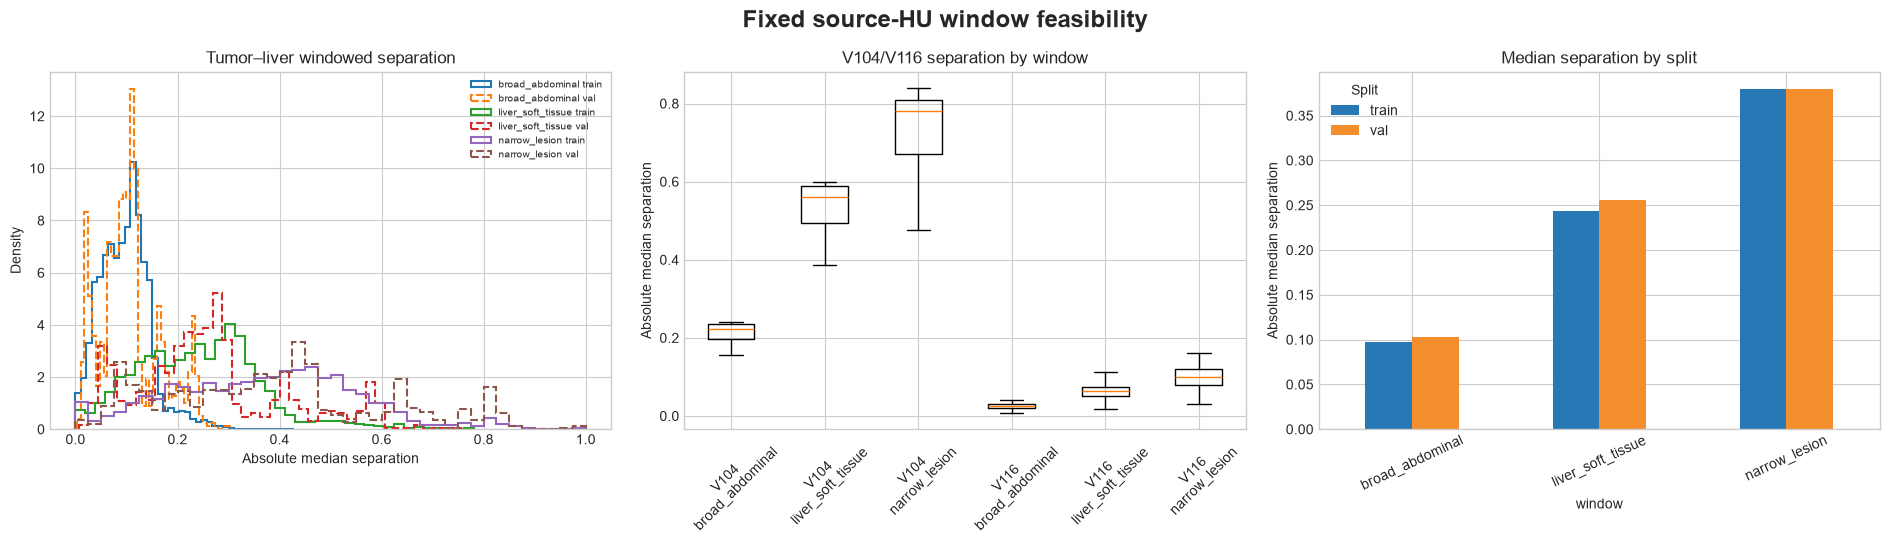

In [10]:
figure, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for name in WINDOWS:
    train_values = window_slice_statistics.loc[
        window_slice_statistics["split"].eq("train")
        & window_slice_statistics["window"].eq(name),
        "absolute_median_separation",
    ]
    val_values = window_slice_statistics.loc[
        window_slice_statistics["split"].eq("val")
        & window_slice_statistics["window"].eq(name),
        "absolute_median_separation",
    ]
    axes[0].hist(train_values, bins=40, density=True, histtype="step",
                 linewidth=1.5, label=f"{name} train")
    axes[0].hist(val_values, bins=40, density=True, histtype="step",
                 linewidth=1.5, linestyle="--", label=f"{name} val")
axes[0].set_title("Tumor–liver windowed separation")
axes[0].set_xlabel("Absolute median separation"); axes[0].set_ylabel("Density")
axes[0].legend(fontsize=7)

focus = window_slice_statistics.loc[
    window_slice_statistics["split"].eq("val")
    & window_slice_statistics["volume_id"].isin([104, 116])
]
focus_box = [
    focus.loc[
        focus["volume_id"].eq(volume_id) & focus["window"].eq(name),
        "absolute_median_separation",
    ].to_numpy()
    for volume_id in (104, 116) for name in WINDOWS
]
labels = [f"V{v}\n{name}" for v in (104, 116) for name in WINDOWS]
axes[1].boxplot(focus_box, tick_labels=labels, showfliers=False)
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("V104/V116 separation by window")
axes[1].set_ylabel("Absolute median separation")

summary_pivot = window_summary.pivot(
    index="window", columns="split", values="median_absolute_separation"
)
summary_pivot.plot.bar(ax=axes[2], color=["#2878B5", "#F28E2B"])
axes[2].set_title("Median separation by split")
axes[2].set_ylabel("Absolute median separation")
axes[2].tick_params(axis="x", rotation=25)
axes[2].legend(title="Split")

figure.suptitle("Fixed source-HU window feasibility", fontsize=17, weight="bold")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "multiwindow_feasibility_dashboard.png",
               dpi=170, bbox_inches="tight")
plt.show()

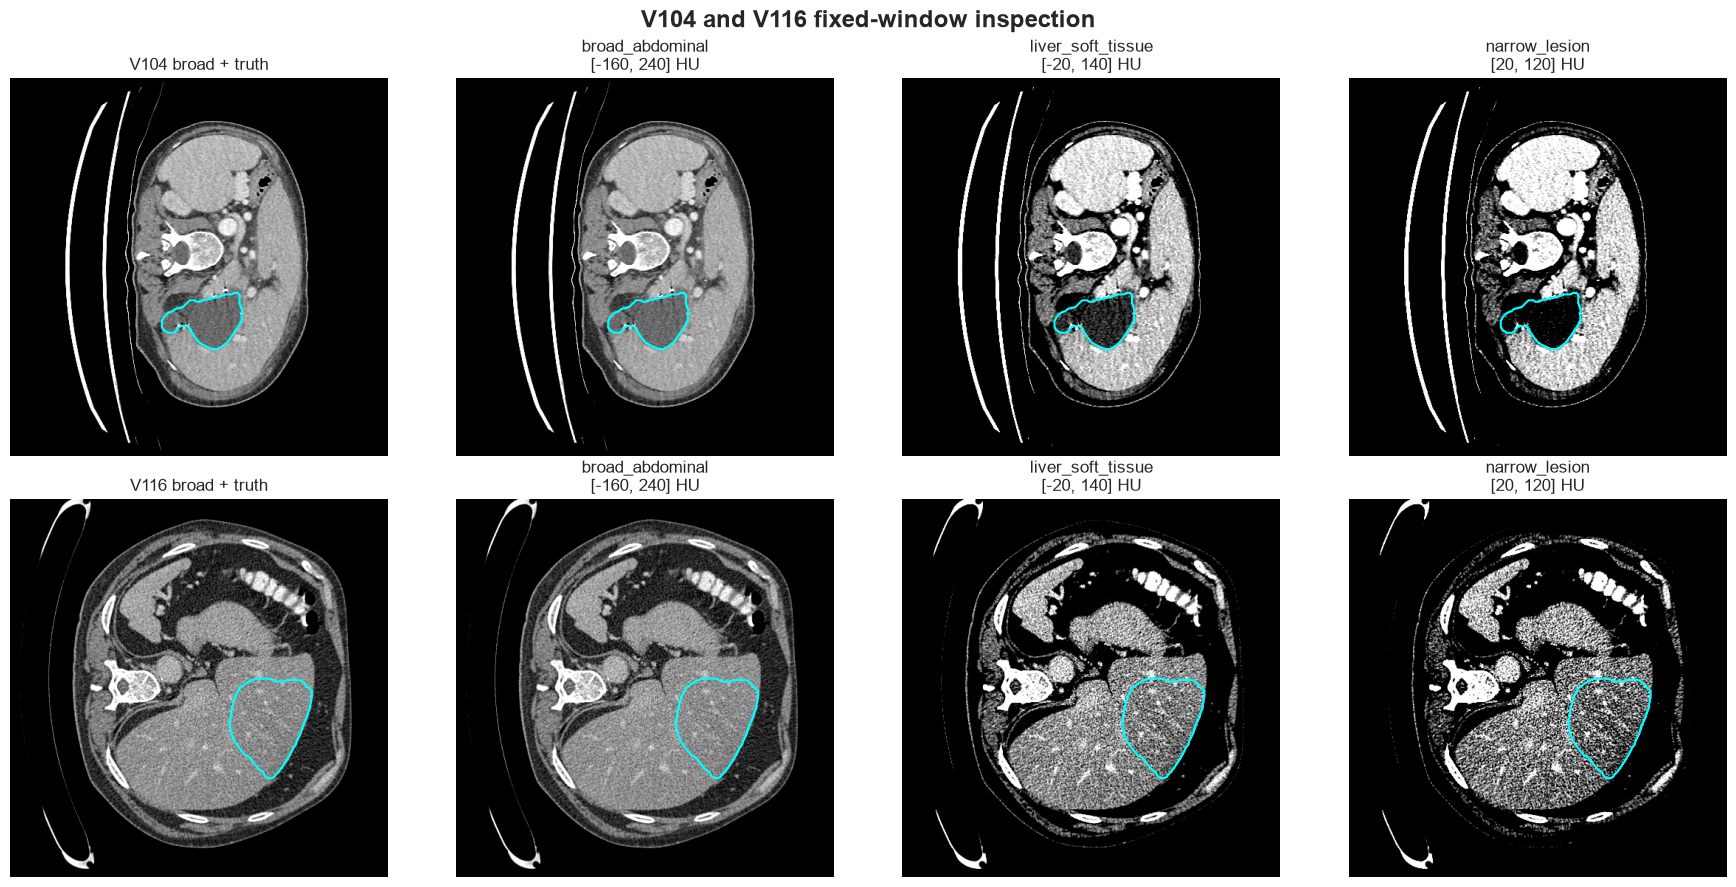

In [11]:
def source_slice(volume_id, slice_index):
    row = validation_manifest.loc[
        validation_manifest["volume_id"].eq(volume_id)
        & validation_manifest["slice_index"].eq(slice_index)
    ].iloc[0]
    ct = nib.load(str(row["source_volume_path"]))
    segmentation = nib.load(str(row["source_segmentation_path"]))
    hu = np.asanyarray(ct.dataobj[:, :, slice_index]).astype(np.float32)
    labels = transform_labels(
        np.asanyarray(segmentation.dataobj[:, :, slice_index]).astype(np.uint8),
        str(row["transform_applied"]),
    )
    return hu, labels

figure, axes = plt.subplots(2, len(WINDOWS) + 1, figsize=(18, 9))
for row_axes, volume_id in zip(axes, [104, 116]):
    item = probability_cache[volume_id]
    index = int(np.argmax(item["tumor_truth"].sum(axis=(1, 2))))
    slice_index = int(item["slice_index"][index])
    hu, labels = source_slice(volume_id, slice_index)
    tumor = labels == 2
    row_axes[0].imshow(hu, cmap="gray", vmin=-160, vmax=240)
    row_axes[0].contour(tumor, levels=[0.5], colors=["#00FFFF"])
    row_axes[0].set_title(f"V{volume_id} broad + truth")
    for axis, (name, (lower, upper)) in zip(row_axes[1:], WINDOWS.items()):
        axis.imshow(apply_window(hu, lower, upper), cmap="gray", vmin=0, vmax=1)
        axis.contour(tumor, levels=[0.5], colors=["#00FFFF"])
        axis.set_title(f"{name}\n[{lower:.0f}, {upper:.0f}] HU")
    for axis in row_axes:
        axis.axis("off")
figure.suptitle("V104 and V116 fixed-window inspection",
               fontsize=17, weight="bold")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "v104_v116_multiwindow_examples.png",
               dpi=170, bbox_inches="tight")
plt.show()

## Takeaways

### 10. Write the Mark 2 feasibility gate and next action

In [12]:
roi_hard_passed = bool(selected_roi["hard_containment_gate_passed"])
roi_efficient_passed = bool(selected_roi["efficient_roi_gate_passed"])

focus_window_summary = (
    window_slice_statistics.loc[
        window_slice_statistics["split"].eq("val")
        & window_slice_statistics["volume_id"].isin([104, 116])
    ]
    .groupby(["volume_id", "window"])
    .agg(
        median_separation=("absolute_median_separation", "median"),
        tumor_low_saturation_pct=("tumor_low_saturation_pct", "median"),
        tumor_high_saturation_pct=("tumor_high_saturation_pct", "median"),
    )
    .reset_index()
)
focus_window_summary.to_csv(
    OUTPUT_DIR / "v104_v116_window_summary.csv", index=False
)

if not roi_hard_passed:
    decision = "REVISE_LIVER_LOCALIZATION_OR_USE_SAFER_ANATOMY_ROI"
    next_notebook = "mark_2b_liver_roi_recovery"
elif roi_hard_passed and not roi_efficient_passed:
    decision = "ROI_CONTAINS_TUMOR_BUT_CROP_IS_TOO_BROAD"
    next_notebook = "mark_2b_roi_efficiency_ablation"
else:
    decision = "PROCEED_TO_GATED_TWO_STAGE_MULTIWINDOW_OVERFIT"
    next_notebook = "mark_3_two_stage_multiwindow_overfit"

gate_result = {
    "status": "mark_2_feasibility_complete",
    "roi_hard_containment_gate_passed": roi_hard_passed,
    "roi_efficiency_gate_passed": roi_efficient_passed,
    "selected_roi_configuration": {
        key: (
            selected_roi[key].item()
            if hasattr(selected_roi[key], "item")
            else selected_roi[key]
        )
        for key in selected_roi.index
    },
    "fixed_windows": {key: list(value) for key, value in WINDOWS.items()},
    "decision": decision,
    "next_notebook": next_notebook,
    "manifest_sha256": EXPECTED_MANIFEST_SHA256,
    "mark1_checkpoint_sha256": EXPECTED_CHECKPOINT_SHA256,
    "roi_uses_ground_truth": False,
    "test_images_accessed": False,
}
(OUTPUT_DIR / "mark_2_gate_result.json").write_text(
    json.dumps(gate_result, indent=2), encoding="utf-8"
)
display(pd.DataFrame([gate_result]).T.rename(columns={0: "value"}))
display(focus_window_summary)
print("DECISION:", decision)

,value
status,mark_2_feasibility_complete
roi_hard_containment_gate_passed,True
roi_efficiency_gate_passed,True
selected_roi_configuration,"{'liver_threshold': 0.5, 'padding': 16, 'compo..."
fixed_windows,"{'broad_abdominal': [-160.0, 240.0], 'liver_so..."
decision,PROCEED_TO_GATED_TWO_STAGE_MULTIWINDOW_OVERFIT
next_notebook,mark_3_two_stage_multiwindow_overfit
manifest_sha256,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...
mark1_checkpoint_sha256,9c4160bbd68891f9dc4e5f04ceca4391f38c5869b3f81c...
roi_uses_ground_truth,False


,volume_id,window,median_separation,tumor_low_saturation_pct,tumor_high_saturation_pct
0,104,broad_abdominal,0.223750,0.000000,0.000000
1,104,liver_soft_tissue,0.559375,5.944323,0.000000
2,104,narrow_lesion,0.780000,71.602424,0.000000
3,116,broad_abdominal,0.025000,0.000000,0.000000
4,116,liver_soft_tissue,0.062500,0.611621,0.903614
5,116,narrow_lesion,0.100000,11.697008,2.541528


DECISION: PROCEED_TO_GATED_TWO_STAGE_MULTIWINDOW_OVERFIT


### Interpretation contract

- A failed ROI containment gate blocks two-stage tumor training. Improve liver localization
  or use a safer anatomy/body ROI; do not hide the failure with ground-truth crops.
- A passing but inefficient ROI supports an ROI design ablation, not full tumor training.
- Only a globally passing ROI permits a 16-slice two-stage overfit experiment.
- Window results are diagnostic. They justify fixed input channels but do not prove that a
  trained model will improve.
- V104 and V116 must both remain explicit guardrails.
- The test split remains locked until a later complete validation configuration passes every
  declared tumor and false-positive target.